# GRA: signum cifar

project = ```GRA```, host = ```yoru```, device = ```cuda:1```

## Goals:

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


def _plot(results, intvl=slice(-21, None), smooth=None, ylim=None, figsize=(9, 4), dpi=100):

    fig, ax = create_figure(1, 1, figsize=figsize, dpi=dpi)

    for i, (k, d) in enumerate(results.items()):
        color = f"C{i}"

        mu = d['test_acc'].mean(0)
        sd = d['test_acc'].std(0)

        if smooth is not None:
            mu = smooth_savgol(mu, smooth, polyorder=3)
            sd = smooth_savgol(sd, smooth, polyorder=3)
            
        xs = np.arange(1, len(mu) + 1)

        xs = xs[intvl]
        mu = mu[intvl]
        sd = sd[intvl]

        ax.plot(xs, mu + sd, color=color, ls='--', lw=0.8, alpha=1.0)
        ax.plot(xs, mu, color=color, label=k, marker='.')
        ax.plot(xs, mu - sd, color=color, ls='--', lw=0.8, alpha=1.0)
        plt.fill_between(xs, mu - sd, mu + sd, color=color, alpha=0.1)

    if ylim is not None:
        ax.set(ylim=ylim)

    ax.legend()
    move_legend(ax, (1.01, 1.01))
    plt.show()

    return

In [3]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## Main

In [4]:
from optimizers import *
from test.test import *

## CIFAR10

`batch_size=256`

In [5]:
cfg = TrainConfig(
    dataset='CIFAR10',
    batch_size=256,
    epochs=200,
    device=device,
    data_on_device=True,
    verbose=True,
    amp=False,
)

### Signum

In [6]:
experiments = []


for lr in [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]:
    for beta1 in [0.8, 0.95]:
        for weight_decay in [0.1]:

            opt_kws = dict(lr=lr, momentum=beta1, weight_decay=weight_decay)
            base_str = f"lr={lr},beta={beta1},wd={weight_decay}"
            
            experiments.extend([
                Experiment(
                    name=f'Rel. Signum ({base_str},mass=10)',
                    opt_fn=make_opt(RelativisticSignum, mass=10, **opt_kws)),
                Experiment(
                    name=f'Rel. Signum ({base_str},mass=5)',
                    opt_fn=make_opt(RelativisticSignum, mass=5, **opt_kws)),
                Experiment(
                    name=f'Rel. Signum ({base_str},mass=1)',
                    opt_fn=make_opt(RelativisticSignum, mass=1, **opt_kws)),
                Experiment(
                    name=f'Rel. Signum ({base_str},mass=0.1)',
                    opt_fn=make_opt(RelativisticSignum, mass=0.1, **opt_kws)),
                Experiment(
                    name=f'Signum ({base_str},dampening=0.0)',
                    opt_fn=make_opt(SignSGD, dampening=0.0, **opt_kws)),
                Experiment(
                    name=f'Signum ({base_str},dampening=0.1)',
                    opt_fn=make_opt(SignSGD, dampening=0.1, **opt_kws)),
                Experiment(
                    name=f'Signum ({base_str},dampening=0.5)',
                    opt_fn=make_opt(SignSGD, dampening=0.5, **opt_kws)),
                Experiment(
                    name=f'AdamW ({base_str})',
                    opt_fn=make_opt(torch.optim.AdamW, lr=lr,
                                    betas=(beta1, beta1),
                                    weight_decay=weight_decay)),
            ])
            
print(len(experiments))

80

In [7]:
print(experiments)

[
    Experiment(
        name='Rel. Signum (lr=0.0001,beta=0.8,wd=0.1,mass=10)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693afb00>
    ),
    Experiment(
        name='Rel. Signum (lr=0.0001,beta=0.8,wd=0.1,mass=5)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693afba0>
    ),
    Experiment(
        name='Rel. Signum (lr=0.0001,beta=0.8,wd=0.1,mass=1)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693afc40>
    ),
    Experiment(
        name='Rel. Signum (lr=0.0001,beta=0.8,wd=0.1,mass=0.1)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693afce0>
    ),
    Experiment(
        name='Signum (lr=0.0001,beta=0.8,wd=0.1,dampening=0.0)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693afd80>
    ),
    Experiment(
        name='Signum (lr=0.0001,beta=0.8,wd=0.1,dampening=0.1)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693afe20>
    ),
    Experiment(
        name='Signum (lr=0.0001,beta=0.8,wd=0.1,dampening=0.5)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693afec0>
    ),
    Experiment(
        name='AdamW (lr=0.0001,beta=0.8,wd=0.1)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693aff60>
    ),
    Experiment(
        name='Rel. Signum (lr=0.0001,beta=0.95,wd=0.1,mass=10)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e8040>
    ),
    Experiment(
        name='Rel. Signum (lr=0.0001,beta=0.95,wd=0.1,mass=5)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e80e0>
    ),
    Experiment(
        name='Rel. Signum (lr=0.0001,beta=0.95,wd=0.1,mass=1)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e8180>
    ),
    Experiment(
        name='Rel. Signum (lr=0.0001,beta=0.95,wd=0.1,mass=0.1)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e8220>
    ),
    Experiment(
        name='Signum (lr=0.0001,beta=0.95,wd=0.1,dampening=0.0)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e82c0>
    ),
    Experiment(
        name='Signum (lr=0.0001,beta=0.95,wd=0.1,dampening=0.1)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e8400>
    ),
    Experiment(
        name='Signum (lr=0.0001,beta=0.95,wd=0.1,dampening=0.5)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e8540>
    ),
    Experiment(
        name='AdamW (lr=0.0001,beta=0.95,wd=0.1)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e85e0>
    ),
    Experiment(
        name='Rel. Signum (lr=0.0005,beta=0.8,wd=0.1,mass=10)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e8680>
    ),
    Experiment(
        name='Rel. Signum (lr=0.0005,beta=0.8,wd=0.1,mass=5)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e8720>
    ),
    Experiment(
        name='Rel. Signum (lr=0.0005,beta=0.8,wd=0.1,mass=1)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e87c0>
    ),
    Experiment(
        name='Rel. Signum (lr=0.0005,beta=0.8,wd=0.1,mass=0.1)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e8860>
    ),
    Experiment(
        name='Signum (lr=0.0005,beta=0.8,wd=0.1,dampening=0.0)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e8900>
    ),
    Experiment(
        name='Signum (lr=0.0005,beta=0.8,wd=0.1,dampening=0.1)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e89a0>
    ),
    Experiment(
        name='Signum (lr=0.0005,beta=0.8,wd=0.1,dampening=0.5)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e8a40>
    ),
    Experiment(
        name='AdamW (lr=0.0005,beta=0.8,wd=0.1)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e8ae0>
    ),
    Experiment(
        name='Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=10)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e8b80>
    ),
    Experiment(
        name='Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=5)',
        opt_fn=<function make_opt.<locals>._fn at 0x7f6d693e8c20>
    ),
    Experiment(
        name='Rel. Signum (lr=0

In [ ]:
%%time


results = run_experiments(
    experiments,
    cfg=cfg,
    model_class=ConvNet,
    seeds=[0, 1, 2],
)

--- Training (CIFAR10) ---

Model: ConvNet | seed=0
Optimizer: RelativisticSignum

RelativisticSignum (
Parameter Group 0
    lr: 0.0001
    mass: 10
    momentum: 0.8
    weight_decay: 0.1
)

Epoch    1/200:  Train Loss 1.0551  |  Test Acc 72.25%

Epoch    5/200:  Train Loss 0.3284  |  Test Acc 80.25%

Epoch   10/200:  Train Loss 0.1250  |  Test Acc 81.47%

...

Epoch  110/200:  Train Loss 0.0253  |  Test Acc 86.28%

Epoch  115/200:  Train Loss 0.0269  |  Test Acc 86.99%

Epoch  120/200:  Train Loss 0.0240  |  Test Acc 87.24%

Epoch  125/200:  Train Loss 0.0237  |  Test Acc 86.95%

Epoch  130/200:  Train Loss 0.0256  |  Test Acc 85.95%

Training time:

- `CIFAR10`: **???**
- `MNIST`: **17h 31s**

In [ ]:
save_obj(results, file_name='CIFAR10_results_jan03.npy', save_dir=tmp_dir)

In [7]:
avg_scores = {k: np.round(d['test_acc'].mean(0)[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Signum (lr=0.01,beta=0.95,wd=0.1,dampening=0.5)': 10.08,
 'Signum (lr=0.005,beta=0.8,wd=0.1,dampening=0.0)': 10.28,
 'Signum (lr=0.005,beta=0.95,wd=0.1,dampening=0.0)': 10.28,
 'Signum (lr=0.005,beta=0.95,wd=0.1,dampening=0.1)': 10.28,
 'Signum (lr=0.005,beta=0.95,wd=0.1,dampening=0.5)': 10.28,
 'Signum (lr=0.01,beta=0.8,wd=0.1,dampening=0.0)': 10.64,
 'Signum (lr=0.01,beta=0.8,wd=0.1,dampening=0.5)': 10.64,
 'Signum (lr=0.01,beta=0.8,wd=0.1,dampening=0.1)': 10.71,
 'Signum (lr=0.01,beta=0.95,wd=0.1,dampening=0.1)': 17.6,
 'Signum (lr=0.01,beta=0.95,wd=0.1,dampening=0.0)': 18.89,
 'Rel. Signum (lr=0.01,beta=0.95,wd=0.1,mass=0.1)': 35.84,
 'Signum (lr=0.005,beta=0.8,wd=0.1,dampening=0.5)': 37.42,
 'Signum (lr=0.005,beta=0.8,wd=0.1,dampening=0.1)': 37.48,
 'Rel. Signum (lr=0.01,beta=0.95,wd=0.1,mass=1)': 85.42,
 'Rel. Signum (lr=0.01,beta=0.8,wd=0.1,mass=0.1)': 85.68,
 'Rel. Signum (lr=0.005,beta=0.95,wd=0.1,mass=0.1)': 86.78,
 'Rel. Signum (lr=0.005,beta=0.95,wd=0.1,mass=1)': 91.89,
 

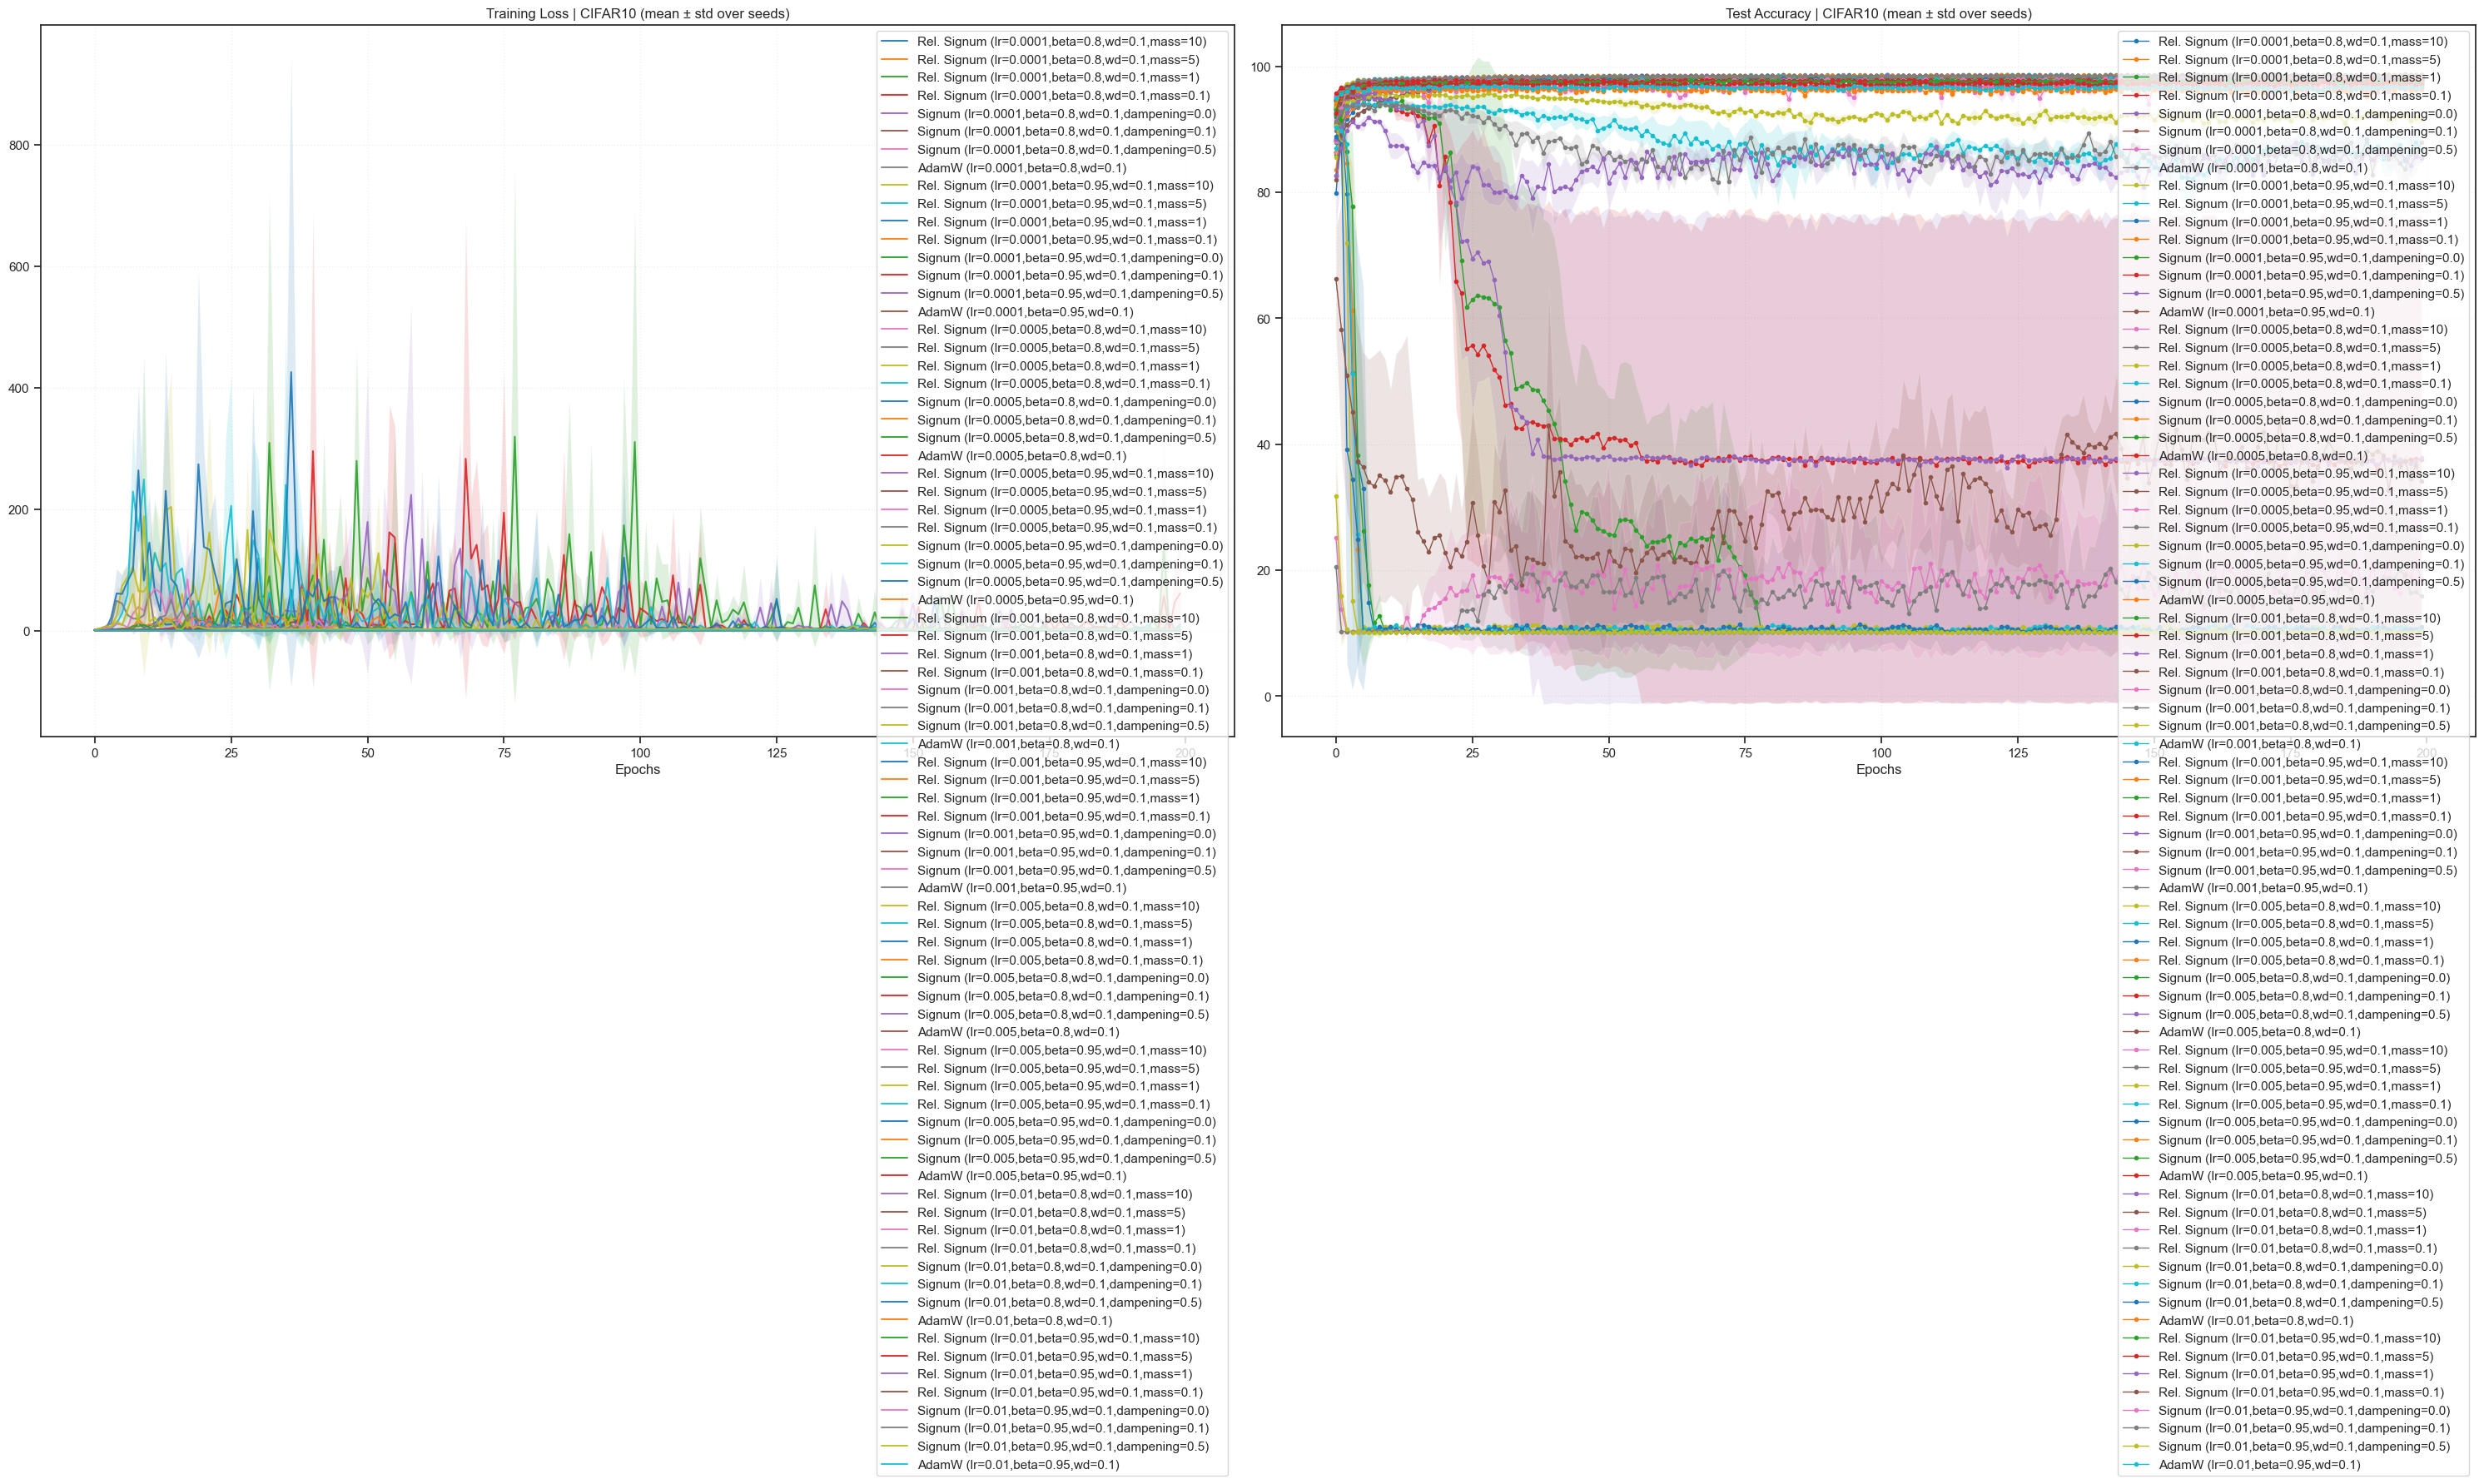

In [8]:
plot_results(results, title="CIFAR10 (mean ± std over seeds)", figsize=(30, 15))

In [9]:
optimizer_names = sorted(set([
    k.split('(')[0].strip()
    for k in results
]))

print(optimizer_names)

['AdamW', 'Rel. Signum', 'Signum']

In [10]:
n_last_timepoints = 10

model_accuracies = collections.defaultdict(dict)

for k, d in results.items():
    name = k.split('(')[0].strip()
    acc = d['test_acc'].mean(0)[-n_last_timepoints:].mean()
    model_accuracies[name][k] = acc

model_accuracies = dict(sorted(model_accuracies.items()))
    
model_accuracies = {
    k: dict(sorted(d.items(), key=lambda t: t[1]))
    for k, d in model_accuracies.items()
}

In [11]:
print(model_accuracies)

{
    'AdamW': {
        'AdamW (lr=0.01,beta=0.8,wd=0.1)': 96.39566666666667,
        'AdamW (lr=0.01,beta=0.95,wd=0.1)': 96.666,
        'AdamW (lr=0.005,beta=0.8,wd=0.1)': 97.52933333333335,
        'AdamW (lr=0.005,beta=0.95,wd=0.1)': 97.76333333333332,
        'AdamW (lr=0.001,beta=0.8,wd=0.1)': 98.37166666666666,
        'AdamW (lr=0.0001,beta=0.8,wd=0.1)': 98.41066666666666,
        'AdamW (lr=0.0001,beta=0.95,wd=0.1)': 98.41266666666667,
        'AdamW (lr=0.0005,beta=0.8,wd=0.1)': 98.43966666666668,
        'AdamW (lr=0.001,beta=0.95,wd=0.1)': 98.471,
        'AdamW (lr=0.0005,beta=0.95,wd=0.1)': 98.54133333333334
    },
    'Rel. Signum': {
        'Rel. Signum (lr=0.01,beta=0.95,wd=0.1,mass=0.1)': 36.562333333333335,
        'Rel. Signum (lr=0.01,beta=0.8,wd=0.1,mass=0.1)': 85.548,
        'Rel. Signum (lr=0.01,beta=0.95,wd=0.1,mass=1)': 85.71300000000001,
        'Rel. Signum (lr=0.005,beta=0.95,wd=0.1,mass=0.1)': 86.571,
        'Rel. Signum (lr=0.005,beta=0.95,wd=0.1,mass=1)': 92.04,
        'Rel. Signum (lr=0.005,beta=0.8,wd=0.1,mass=0.1)': 96.35266666666668,
        'Rel. Signum (lr=0.01,beta=0.8,wd=0.1,mass=1)': 96.646,
        'Rel. Signum (lr=0.01,beta=0.8,wd=0.1,mass=10)': 96.85,
        'Rel. Signum (lr=0.01,beta=0.8,wd=0.1,mass=5)': 97.19533333333334,
        'Rel. Signum (lr=0.01,beta=0.95,wd=0.1,mass=5)': 97.22633333333333,
        'Rel. Signum (lr=0.01,beta=0.95,wd=0.1,mass=10)': 97.40433333333335,
        'Rel. Signum (lr=0.005,beta=0.95,wd=0.1,mass=5)': 97.63933333333333,
        'Rel. Signum (lr=0.005,beta=0.8,wd=0.1,mass=10)': 97.68433333333334,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=0.1)': 97.78333333333333,
        'Rel. Signum (lr=0.005,beta=0.8,wd=0.1,mass=1)': 97.79366666666667,
        'Rel. Signum (lr=0.005,beta=0.95,wd=0.1,mass=10)': 97.84233333333333,
        'Rel. Signum (lr=0.005,beta=0.8,wd=0.1,mass=5)': 97.86533333333334,
        'Rel. Signum (lr=0.001,beta=0.8,wd=0.1,mass=0.1)': 98.06,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=1)': 98.10333333333332,
        'Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=0.1)': 98.22166666666666,
        'Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=1)': 98.31166666666667,
        'Rel. Signum (lr=0.001,beta=0.8,wd=0.1,mass=10)': 98.349,
        'Rel. Signum (lr=0.0005,beta=0.8,wd=0.1,mass=0.1)': 98.36366666666666,
        'Rel. Signum (lr=0.001,beta=0.8,wd=0.1,mass=5)': 98.36433333333333,
        'Rel. Signum (lr=0.0005,beta=0.8,wd=0.1,mass=10)': 98.39133333333334,
        'Rel. Signum (lr=0.001,beta=0.8,wd=0.1,mass=1)': 98.42033333333333,
        'Rel. Signum (lr=0.0005,beta=0.8,wd=0.1,mass=5)': 98.44833333333334,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=10)': 98.466,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=5)': 98.46700000000001,
        'Rel. Signum (lr=0.0001,beta=0.95,wd=0.1,mass=0.1)': 98.50166666666667,
        'Rel. Signum (lr=0.0001,beta=0.8,wd=0.1,mass=0.1)': 98.50833333333333,
        'Rel. Signum (lr=0.0001,beta=0.8,wd=0.1,mass=10)': 98.52133333333333,
        'Rel. Signum (lr=0.0005,beta=0.8,wd=0.1,mass=1)': 98.52166666666668,
        'Rel. Signum (lr=0.0001,beta=0.95,wd=0.1,mass=1)': 98.55233333333334,
        'Rel. Signum (lr=0.0001,beta=0.8,wd=0.1,mass=5)': 98.56099999999999,
        'Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=10)': 98.567,
        'Rel. Signum (lr=0.0001,beta=0.95,wd=0.1,mass=10)': 98.57600000000001,
        'Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=5)': 98.57666666666667,
        'Rel. Signum (lr=0.0001,beta=0.8,wd=0.1,mass=1)': 98.58200000000001,
        'Rel. Signum (lr=0.0001,beta=0.95,wd=0.1,mass=5)': 98.62833333333333
    },
    'Signum': {
        'Signum (lr=0.01,beta=0.95,wd=0.1,dampening=0.5)': 10.123999999999999,
        'Signum (lr=0.005,beta=0.8,wd=0.1,dampening=0.0)': 10.28,
        'Signum (lr=0.005,beta=0.95,wd=0.1,dampening=0.0)': 10.28,
        'Signum (lr=0.005,beta=0.95,wd=0.1,dampening=0.1)': 10.28,
        'Signum (lr=0.005,beta=0.95,wd=0.1,

In [12]:
print({k: np.mean(list(d.values())) for k, d in model_accuracies.items()})

{'AdamW': 97.90013333333334, 'Rel. Signum': 95.46950833333332, 'Signum': 65.28448888888889}

In [13]:
n_top_fits = 2

best_n_models = {
    k: dict(list(d.items())[-n_top_fits:])
    for k, d in model_accuracies.items()
}
print(best_n_models)

{
    'AdamW': {
        'AdamW (lr=0.001,beta=0.95,wd=0.1)': 98.471,
        'AdamW (lr=0.0005,beta=0.95,wd=0.1)': 98.54133333333334
    },
    'Rel. Signum': {
        'Rel. Signum (lr=0.0001,beta=0.8,wd=0.1,mass=1)': 98.58200000000001,
        'Rel. Signum (lr=0.0001,beta=0.95,wd=0.1,mass=5)': 98.62833333333333
    },
    'Signum': {
        'Signum (lr=0.0001,beta=0.95,wd=0.1,dampening=0.5)': 98.38166666666667,
        'Signum (lr=0.0001,beta=0.95,wd=0.1,dampening=0.0)': 98.389
    }
}

In [14]:
best_n_models_strings = [x for d in best_n_models.values() for x in list(d)]

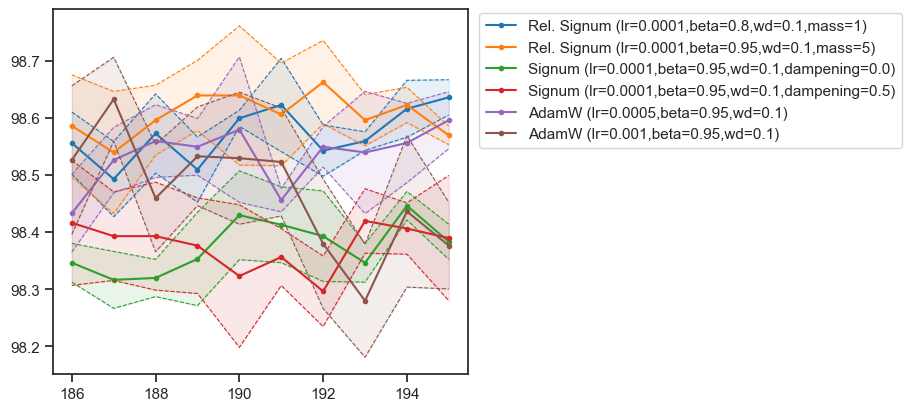

In [18]:
selected_results = {
    k: v for k, v in results.items()
    if k in best_n_models_strings
}

_plot(selected_results, intvl=slice(-15, -5))

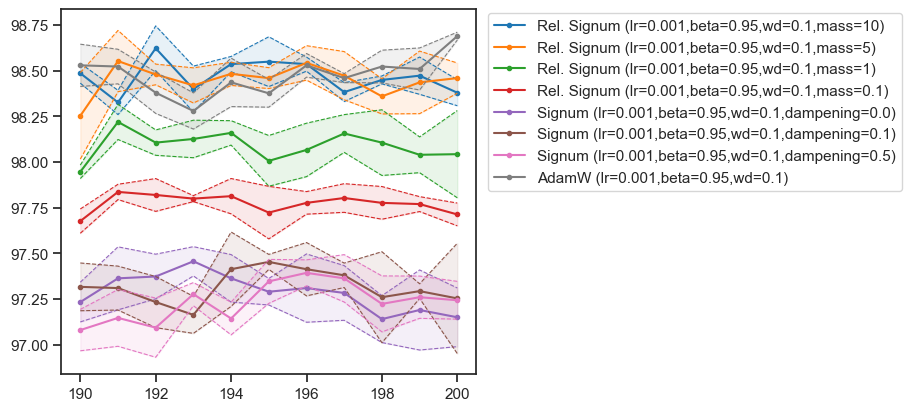

In [21]:
selected_results = {
    k: v for k, v in results.items()
    if 'lr=0.001,beta=0.95' in k
}

_plot(selected_results, intvl=slice(-11, None))